# Self Learning Assignment — Exploring Word Representations
## From Traditional Word Embeddings to Transformers

| | |
|---|---|
| **Name** | **NIVASRI T** |
| **Roll No.** | **24BAD081** |
| **Course Outcome** | CO3 — Bloom's Level K3–K4 (Apply & Analyze) |
| **Topic** | Exploring Word Representations: From Traditional Word Embeddings to Transformers |

**In this Notebook**

1. Literature exploration + comparative table (10 techniques)
2. Traditional representations: One-Hot, BoW, N-grams, TF-IDF, Co-occurrence, SVD/LSA
3. Common dataset (20 Newsgroups) and preprocessing
4. TF-IDF representation and top-5 similar words
5. Word2Vec (Skip-gram and CBOW) + semantic relationships
6. FastText (out-of-vocabulary handling) and GloVe (pretrained)
7. Neural embeddings with TensorFlow/Keras Embedding layer
8. Contextual embeddings: BERT, and sentence embeddings: SBERT
9. Visualization: PCA, t-SNE, UMAP, TensorFlow Embedding Projector export
10. Comparative analysis, conclusion, references


# 0. Setup

In [ ]:
!pip install -q gensim umap-learn sentence-transformers transformers plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 35.5 MB/s eta 0:00:00


In [ ]:
import time, warnings, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", 50, "display.width", 200)
timings = {}   # used later in the computational-requirements comparison
print("Setup complete")

Setup complete


# 1. Literature Exploration

Text must be converted into numbers before a machine-learning model can use it. Representations have evolved through three generations:

1. **Traditional / count-based** – sparse vectors built from counts (One-Hot, BoW, TF-IDF, N-grams).
2. **Static (predictive) embeddings** – dense vectors, one per word, learned from context (Word2Vec, GloVe, FastText, Keras Embedding layer).
3. **Contextual embeddings** – the vector of a word depends on its sentence (ELMo, BERT, RoBERTa, SBERT).

### 1.1 Brief explanation of each technique

**One-Hot Encoding** – every word is a vector of length |V| with a single 1. It has no notion of similarity (all words are equally distant), and dimension grows with vocabulary.

**Bag of Words (BoW)** – a document is a vector of word counts. It ignores word order and treats frequent words as important.

**N-grams** – extends BoW to sequences of n consecutive words (bigrams, trigrams), capturing local order such as *"not good"* at the cost of a much larger feature space.

**TF-IDF** – weights each term by `tf × log(N/df)`: frequent in a document but rare across the corpus means important. Better than BoW, still sparse and not semantic.

**Co-occurrence matrix, SVD and LSA** – count how often words appear near each other, then use Singular Value Decomposition to compress into dense low-rank vectors. When applied to a term-document matrix this is *Latent Semantic Analysis (LSA)*. It captures some synonymy but is a linear, global method.

**Word2Vec (Mikolov et al., 2013)** – a shallow neural network trained to predict words from context.
* *CBOW* predicts the centre word from the average of its context words (fast, good for frequent words).
* *Skip-gram* predicts context words from the centre word (slower, better for rare words).

**GloVe (Pennington et al., 2014)** – factorises the global word co-occurrence matrix by fitting `w_i · w_j + b_i + b_j ≈ log X_ij`. Combines global statistics with local-context learning.

**FastText (Bojanowski et al., 2017)** – a word vector is the sum of vectors of its character n-grams. Can build vectors for rare, misspelt or unseen words.

**Keras Embedding layer** – a trainable lookup table (`vocab_size × dim`) learned end-to-end for a downstream task such as classification.

**ELMo (2018)** – deep bidirectional LSTM language model; word vector = weighted combination of layer outputs, so it depends on context.

**BERT (Devlin et al., 2018)** – bidirectional Transformer encoder pre-trained with masked-language modelling and next-sentence prediction; each token's vector depends on the full sentence. **RoBERTa** improves BERT by training longer on more data, removing NSP and using dynamic masking.

**Sentence-BERT (SBERT) and Universal Sentence Encoder (USE)** – produce a single fixed-size vector for a whole sentence so that sentence similarity can be computed efficiently by cosine similarity.

### 1.2 Comparative table (10 techniques)

| # | Technique | Type | Vector | Captures semantics? | Context-aware? | Handles OOV? | Order captured? | Compute cost | Main limitation |
|---|---|---|---|---|---|---|---|---|---|
| 1 | One-Hot | Count / symbolic | Sparse, \|V\| dims | No | No | No | No | Very low | No similarity, huge dimension |
| 2 | Bag of Words | Count | Sparse | Weak | No | No | No | Low | Ignores order and meaning |
| 3 | N-grams | Count | Sparse, very large | Weak | Local only | No | Partially | Low–Medium | Feature explosion, sparsity |
| 4 | TF-IDF | Weighted count | Sparse | Weak (term importance) | No | No | No | Low | No semantic similarity between different words |
| 5 | Co-occurrence + SVD / LSA | Matrix factorisation | Dense, 50–300 | Moderate (global) | No | No | No | Medium (SVD) | Linear, expensive for large vocab |
| 6 | Word2Vec (CBOW / Skip-gram) | Predictive, static | Dense, 100–300 | Strong | No | No | Window only | Medium | One vector per word (polysemy), OOV fails |
| 7 | GloVe | Global-matrix, static | Dense, 50–300 | Strong | No | No | Window only | Medium | Static, fixed vocabulary |
| 8 | FastText | Predictive, sub-word | Dense, 100–300 | Strong | No | **Yes** (char n-grams) | Window only | Medium–High | Static, larger model |
| 9 | Keras Embedding layer | Task-trained, static | Dense, user-chosen | Task-specific | No | No (maps to UNK) | No (unless RNN/CNN follows) | Low–Medium | Needs labelled data, quality depends on task |
| 10 | ELMo | Contextual (BiLSTM) | Dense, 1024 | Strong | **Yes** | Yes (char-CNN) | Yes | High | Slower than static, sequential |
| 11 | BERT / RoBERTa | Contextual (Transformer) | Dense, 768 | Very strong | **Yes** | Yes (WordPiece / BPE) | Yes | Very high | Heavy memory/GPU, 512-token limit |
| 12 | SBERT / USE | Sentence embedding | Dense, 384–768 | Very strong (sentence level) | Yes | Yes | Yes | High (fast at inference vs raw BERT pairs) | Sentence-level, not word-level |

# 2. Traditional Text Representations (toy corpus)

A tiny corpus makes the matrices easy to read.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

toy = ["the king rules the kingdom",
       "the queen rules the kingdom",
       "a man walks the dog",
       "a woman walks the dog"]

# ---------- One-Hot Encoding (word level) ----------
cv = CountVectorizer()
cv.fit(toy)
vocab_toy = cv.get_feature_names_out()
one_hot = pd.DataFrame(np.eye(len(vocab_toy), dtype=int), index=vocab_toy, columns=vocab_toy)
print("One-Hot encoding (each row = one word):")
display(one_hot)

One-Hot encoding (each row = one word):


,dog,king,kingdom,man,queen,rules,the,walks,woman
dog,1,0,0,0,0,0,0,0,0
king,0,1,0,0,0,0,0,0,0
kingdom,0,0,1,0,0,0,0,0,0
man,0,0,0,1,0,0,0,0,0
queen,0,0,0,0,1,0,0,0,0
rules,0,0,0,0,0,1,0,0,0
the,0,0,0,0,0,0,1,0,0
walks,0,0,0,0,0,0,0,1,0
woman,0,0,0,0,0,0,0,0,1


In [ ]:
# ---------- Bag of Words ----------
bow = pd.DataFrame(cv.transform(toy).toarray(), columns=vocab_toy, index=[f"doc{i+1}" for i in range(len(toy))])
print("Bag of Words:")
display(bow)

# ---------- N-grams (unigrams + bigrams) ----------
cv2 = CountVectorizer(ngram_range=(1, 2))
ng = pd.DataFrame(cv2.fit_transform(toy).toarray(), columns=cv2.get_feature_names_out(),
                  index=[f"doc{i+1}" for i in range(len(toy))])
print(f"\nUnigram+Bigram features: {ng.shape[1]} (vs {bow.shape[1]} for BoW)")
display(ng.loc[:, ng.columns.str.contains(" ")])

# ---------- TF-IDF ----------
tv = TfidfVectorizer()
tfidf_toy = pd.DataFrame(tv.fit_transform(toy).toarray().round(3), columns=tv.get_feature_names_out(),
                         index=[f"doc{i+1}" for i in range(len(toy))])
print("\nTF-IDF (note 'the' and 'rules' get low weight, 'king'/'queen' get high weight):")
display(tfidf_toy)

Bag of Words:


,dog,king,kingdom,man,queen,rules,the,walks,woman
doc1,0,1,1,0,0,1,2,0,0
doc2,0,0,1,0,1,1,2,0,0
doc3,1,0,0,1,0,0,1,1,0
doc4,1,0,0,0,0,0,1,1,1



Unigram+Bigram features: 19 (vs 9 for BoW)


,king rules,man walks,queen rules,rules the,the dog,the king,the kingdom,the queen,walks the,woman walks
doc1,1,0,0,1,0,1,1,0,0,0
doc2,0,0,1,1,0,0,1,1,0,0
doc3,0,1,0,0,1,0,0,0,1,0
doc4,0,0,0,0,1,0,0,0,1,1



TF-IDF (note 'the' and 'rules' get low weight, 'king'/'queen' get high weight):


,dog,king,kingdom,man,queen,rules,the,walks,woman
doc1,0.000,0.548,0.432,0.000,0.000,0.432,0.572,0.000,0.000
doc2,0.000,0.000,0.432,0.000,0.548,0.432,0.572,0.000,0.000
doc3,0.497,0.000,0.000,0.631,0.000,0.000,0.329,0.497,0.000
doc4,0.497,0.000,0.000,0.000,0.000,0.000,0.329,0.497,0.631


Co-occurrence matrix:


,a,dog,king,kingdom,man,queen,rules,the,walks,woman
a,0,0,0,0,1,0,0,0,2,1
dog,0,0,0,0,0,0,0,2,2,0
king,0,0,0,0,0,0,1,2,0,0
kingdom,0,0,0,0,0,0,2,2,0,0
man,1,0,0,0,0,0,0,1,1,0
queen,0,0,0,0,0,0,1,2,0,0
rules,0,0,1,2,0,1,0,4,0,0
the,0,2,2,2,1,2,4,0,2,1
walks,2,2,0,0,1,0,0,2,0,1
woman,1,0,0,0,0,0,0,1,1,0


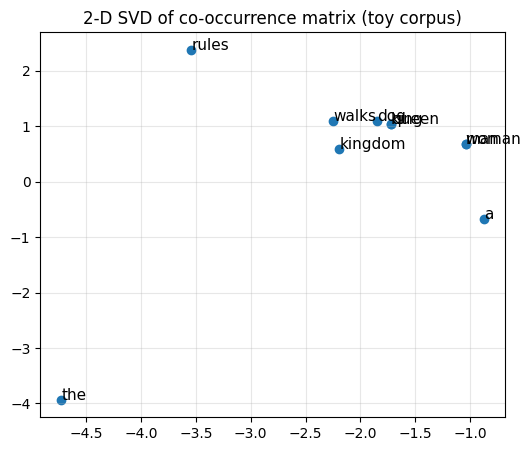

In [ ]:
# ---------- Co-occurrence matrix + SVD (LSA-style) ----------
tokens = [s.split() for s in toy]
vocab = sorted({w for s in tokens for w in s}); idx = {w: i for i, w in enumerate(vocab)}
C = np.zeros((len(vocab), len(vocab)))
window = 2
for s in tokens:
    for i, w in enumerate(s):
        for j in range(max(0, i - window), min(len(s), i + window + 1)):
            if i != j:
                C[idx[w], idx[s[j]]] += 1
print("Co-occurrence matrix:")
display(pd.DataFrame(C.astype(int), index=vocab, columns=vocab))

U, S, Vt = np.linalg.svd(C)
W2 = U[:, :2] * S[:2]
plt.figure(figsize=(6, 5))
plt.scatter(W2[:, 0], W2[:, 1])
for w, (x, y) in zip(vocab, W2):
    plt.annotate(w, (x, y), fontsize=11)
plt.title("2-D SVD of co-occurrence matrix (toy corpus)")
plt.grid(alpha=.3); plt.show()

**Observation.** One-hot gives no similarity at all (`king·queen = 0`). BoW/TF-IDF are document-level and sparse. The SVD of the co-occurrence matrix places words that occur in similar contexts (*king/queen*, *man/woman*) close together, which is the first step towards dense semantic embeddings.

**Limitations of traditional methods:** high dimensionality, sparsity, no semantic similarity, no word-order (except n-grams), cannot handle unseen words.

# 3. Common Dataset — 20 Newsgroups

We use the **20 Newsgroups** corpus (~18,000 posts across 20 topics such as space, baseball, medicine, cars, religion and computer graphics). It is large enough to train meaningful Word2Vec / FastText models and has natural topic clusters that are ideal for visualization.

In [ ]:
from sklearn.datasets import fetch_20newsgroups
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS

raw = fetch_20newsgroups(subset="all", remove=("headers", "footers", "quotes"))

def prep(text):
    return [w for w in simple_preprocess(text, deacc=True, min_len=2, max_len=20) if w not in STOPWORDS]

sentences_all = [prep(t) for t in raw.data]
keep = [i for i, s in enumerate(sentences_all) if len(s) >= 10]
sentences = [sentences_all[i] for i in keep]
labels = np.array(raw.target)[keep]
label_names = raw.target_names
docs = [" ".join(s) for s in sentences]

print("Documents kept :", len(sentences))
print("Total tokens   :", sum(len(s) for s in sentences))
print("Unique tokens  :", len({w for s in sentences for w in s}))
print("Example        :", sentences[0][:20])

Documents kept : 16628
Total tokens   : 1713427
Unique tokens  : 95832
Example        : ['sure', 'bashers', 'pens', 'fans', 'pretty', 'confused', 'lack', 'kind', 'posts', 'recent', 'pens', 'massacre', 'devils', 'actually', 'bit', 'puzzled', 'bit', 'relieved', 'going', 'end']


# 4. TF-IDF Representation + Top-5 Similar Words (cosine similarity)

Here each **word** is represented by its column in the TF-IDF matrix (a vector over documents). Words appearing in the same documents get high cosine similarity.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

t0 = time.time()
tfidf = TfidfVectorizer(tokenizer=lambda x: x, preprocessor=lambda x: x, token_pattern=None,
                        lowercase=False, min_df=5, max_df=0.5)
X = tfidf.fit_transform(sentences)               # docs x terms (sparse)
timings["TF-IDF (fit)"] = time.time() - t0
terms = tfidf.get_feature_names_out()
term_idx = {w: i for i, w in enumerate(terms)}
XT = X.T.tocsr()                                  # terms x docs

print("TF-IDF matrix shape:", X.shape, "| sparsity: %.2f%%" % (100 * (1 - X.nnz / (X.shape[0] * X.shape[1]))))

def tfidf_similar(word, k=5):
    if word not in term_idx:
        return []
    i = term_idx[word]
    sims = cosine_similarity(XT[i], XT).ravel()
    sims[i] = -1
    top = sims.argsort()[::-1][:k]
    return [(terms[j], round(float(sims[j]), 3)) for j in top]

query_words = ["space", "computer", "god", "car", "game", "doctor"]
query_words = [w for w in query_words if w in term_idx]
for w in query_words:
    print(f"{w:10s} ->", tfidf_similar(w))

TF-IDF matrix shape: (16628, 21760) | sparsity: 99.73%
space      -> [('nasa', 0.286), ('shuttle', 0.239), ('aeronautics', 0.192), ('sci', 0.182), ('launch', 0.181)]
god        -> [('jesus', 0.265), ('bible', 0.261), ('christ', 0.248), ('existence', 0.247), ('faith', 0.244)]
car        -> [('cars', 0.212), ('engine', 0.172), ('dealer', 0.155), ('miles', 0.153), ('mileage', 0.151)]
game       -> [('games', 0.267), ('espn', 0.261), ('baseball', 0.215), ('hockey', 0.209), ('scored', 0.196)]
doctor     -> [('clinic', 0.244), ('stitches', 0.225), ('clothed', 0.184), ('resembled', 0.175), ('prescription', 0.164)]


# 5. Word2Vec — Skip-gram and CBOW (Gensim)

In [ ]:
from gensim.models import Word2Vec

params = dict(vector_size=100, window=5, min_count=5, workers=4, epochs=10, seed=42)

t0 = time.time(); w2v_sg = Word2Vec(sentences, sg=1, **params); timings["Word2Vec Skip-gram (train)"] = time.time() - t0
t0 = time.time(); w2v_cbow = Word2Vec(sentences, sg=0, **params); timings["Word2Vec CBOW (train)"] = time.time() - t0

print("Vocabulary size :", len(w2v_sg.wv))
print("Skip-gram time  : %.1fs | CBOW time: %.1fs" % (timings["Word2Vec Skip-gram (train)"], timings["Word2Vec CBOW (train)"]))

Vocabulary size : 26057
Skip-gram time  : 155.8s | CBOW time: 53.2s


In [ ]:
# ---- Five most similar words (cosine similarity) for the query words ----
def top5(model, word, k=5):
    wv = model.wv
    return [(w, round(float(s), 3)) for w, s in wv.most_similar(word, topn=k)] if word in wv else []

rows = []
for w in query_words:
    rows.append({"query": w,
                 "TF-IDF": ", ".join(x for x, _ in tfidf_similar(w)),
                 "Word2Vec Skip-gram": ", ".join(x for x, _ in top5(w2v_sg, w)),
                 "Word2Vec CBOW": ", ".join(x for x, _ in top5(w2v_cbow, w))})
sim_table = pd.DataFrame(rows).set_index("query")
display(sim_table)

,TF-IDF,Word2Vec Skip-gram,Word2Vec CBOW
query,,,
space,"nasa, shuttle, aeronautics, sci, launch","shuttles, investor, hubble, larrison, shuttle","shuttle, advertising, shuttles, billboards, po..."
god,"jesus, bible, christ, existence, faith","spirits, incarnate, subsistence, whosoever, om...","spirit, salvation, creator, grace, lord"
car,"cars, engine, dealer, miles, mileage","cars, volvo, svx, dealership, sentra","cars, tires, volvo, tire, passenger"
game,"games, espn, baseball, hockey, scored","nords, televised, isles, habs, games","games, score, caps, espn, played"
doctor,"clinic, stitches, clothed, resembled, prescrip...","septra, physician, nurse, prescription, medica...","medication, doctors, physician, prescription, ..."


In [ ]:
# ---- Detailed cosine scores for Skip-gram ----
for w in query_words:
    print(f"\nTop-5 for '{w}' (Skip-gram):")
    for word, score in top5(w2v_sg, w):
        print(f"   {word:15s} cosine = {score}")


Top-5 for 'space' (Skip-gram):
   shuttles        cosine = 0.683
   investor        cosine = 0.669
   hubble          cosine = 0.658
   larrison        cosine = 0.652
   shuttle         cosine = 0.644

Top-5 for 'god' (Skip-gram):
   spirits         cosine = 0.758
   incarnate       cosine = 0.753
   subsistence     cosine = 0.752
   whosoever       cosine = 0.75
   omniscience     cosine = 0.748

Top-5 for 'car' (Skip-gram):
   cars            cosine = 0.74
   volvo           cosine = 0.735
   svx             cosine = 0.723
   dealership      cosine = 0.723
   sentra          cosine = 0.711

Top-5 for 'game' (Skip-gram):
   nords           cosine = 0.762
   televised       cosine = 0.741
   isles           cosine = 0.732
   habs            cosine = 0.732
   games           cosine = 0.728

Top-5 for 'doctor' (Skip-gram):
   septra          cosine = 0.735
   physician       cosine = 0.721
   nurse           cosine = 0.72
   prescription    cosine = 0.719
   medication      cosine = 0.7

In [ ]:
# ---- Semantic relationships: similarity, odd-one-out, analogies ----
wv = w2v_sg.wv
pairs = [("space", "nasa"), ("car", "engine"), ("doctor", "patients"), ("god", "jesus"), ("space", "baseball")]
print("Pairwise cosine similarity:")
for a, b in pairs:
    if a in wv and b in wv:
        print(f"  sim({a}, {b}) = {wv.similarity(a, b):.3f}")

print("\nOdd one out:")
for group in (["baseball", "hockey", "nasa", "team"], ["car", "engine", "bike", "jesus"]):
    group = [g for g in group if g in wv]
    print("  ", group, "->", wv.doesnt_match(group))

print("\nAnalogies (A - B + C):")
analogies = [(["jesus", "church"], ["god"]), (["nasa", "baseball"], ["space"]), (["windows", "mac"], ["dos"])]
for pos, neg in analogies:
    if all(w in wv for w in pos + neg):
        print(f"  {pos} - {neg} ->", [w for w, _ in wv.most_similar(positive=pos, negative=neg, topn=3)])

Pairwise cosine similarity:
  sim(space, nasa) = 0.474
  sim(car, engine) = 0.579
  sim(doctor, patients) = 0.643
  sim(god, jesus) = 0.700
  sim(space, baseball) = 0.257

Odd one out:
   ['baseball', 'hockey', 'nasa', 'team'] -> nasa
   ['car', 'engine', 'bike', 'jesus'] -> jesus

Analogies (A - B + C):
  ['jesus', 'church'] - ['god'] -> ['churches', 'protestant', 'disciples']
  ['nasa', 'baseball'] - ['space'] -> ['sanders', 'telecasts', 'gov']
  ['windows', 'mac'] - ['dos'] -> ['quadra', 'macintosh', 'powerbook']


**Observation.** Skip-gram and CBOW return topic-coherent neighbours (e.g. *space → nasa, orbit, shuttle*), while TF-IDF neighbours are driven by document co-presence and often contain rarer, noisier words. Skip-gram generally gives better quality for less frequent words; CBOW trains faster. Analogy quality is limited because this corpus (~3 M tokens) is far smaller than the billions of tokens used by the original papers.

# 6. FastText (OOV handling) and GloVe (pretrained)

### 6.1 FastText trained on the same corpus

In [ ]:
from gensim.models import FastText

t0 = time.time()
ft = FastText(sentences, vector_size=100, window=5, min_count=5, sg=1, min_n=3, max_n=6, epochs=10, workers=4, seed=42)
timings["FastText (train)"] = time.time() - t0
print("FastText training time: %.1fs" % timings["FastText (train)"])

# Out-of-vocabulary / misspelt / rare words
oov_words = ["computr", "spaceflights", "baseballs", "graphicss", "doctorate", "nasaa"]
rows = []
for w in oov_words:
    in_w2v = w in w2v_sg.wv
    in_ft_vocab = w in ft.wv.key_to_index
    vec = ft.wv[w]                       # works even if not in vocabulary (built from char n-grams)
    nn = [x for x, _ in ft.wv.most_similar(positive=[vec], topn=5)]
    rows.append({"word": w, "in Word2Vec vocab": in_w2v, "in FastText vocab": in_ft_vocab,
                 "Word2Vec result": "KeyError / no vector" if not in_w2v else "vector available",
                 "FastText nearest neighbours": ", ".join(nn)})
display(pd.DataFrame(rows).set_index("word"))

FastText training time: 265.4s


,in Word2Vec vocab,in FastText vocab,Word2Vec result,FastText nearest neighbours
word,,,,
computr,False,False,KeyError / no vector,"computrac, compute, computing, computes, compuadd"
spaceflights,False,False,KeyError / no vector,"spaceflight, spacecause, spacewalk, spacewalks..."
baseballs,False,False,KeyError / no vector,"baseball, eyeball, ballgame, basketball, fastball"
graphicss,False,False,KeyError / no vector,"graphics, graphic, graphing, graphite, graphical"
doctorate,False,False,KeyError / no vector,"doctoral, doctors, doctor, endocrinologist, ph..."
nasaa,False,False,KeyError / no vector,"nasa, nasda, nasp, jsc, dfrf"


In [ ]:
# Explicitly show the failure of Word2Vec on an OOV word
try:
    _ = w2v_sg.wv["computr"]
except KeyError as e:
    print("Word2Vec ->", "KeyError:", str(e)[:80])
print("FastText -> vector of shape", ft.wv["computr"].shape, "generated from character n-grams")

Word2Vec -> KeyError: "Key 'computr' not present"
FastText -> vector of shape (100,) generated from character n-grams


**Observation.** Word2Vec cannot represent a misspelt/unseen word (`KeyError`), while FastText builds a vector from sub-word n-grams (e.g. `<co`, `com`, `omp`, `mpu` …) and still retrieves neighbours such as *computer / computers*. This makes FastText well suited for morphologically rich languages, typos and rare words.

### 6.2 GloVe (pretrained on Wikipedia + Gigaword, 100-d)

In [ ]:
import gensim.downloader as api

t0 = time.time()
glove = api.load("glove-wiki-gigaword-100")
timings["GloVe (load pretrained)"] = time.time() - t0
print("GloVe vocab size:", len(glove), "| load time: %.1fs" % timings["GloVe (load pretrained)"])

for w in ["space", "computer", "doctor", "car", "king"]:
    print(f"{w:10s} ->", [x for x, _ in glove.most_similar(w, topn=5)])

print("\nAnalogy king - man + woman ->", glove.most_similar(positive=["king", "woman"], negative=["man"], topn=3))
print("Analogy paris - france + italy ->", glove.most_similar(positive=["paris", "italy"], negative=["france"], topn=3))

[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe vocab size: 400000 | load time: 84.2s
space      -> ['nasa', 'spaces', 'shuttle', 'earth', 'spacecraft']
computer   -> ['computers', 'software', 'technology', 'pc', 'hardware']
doctor     -> ['physician', 'nurse', 'dr.', 'doctors', 'patient']
car        -> ['vehicle', 'truck', 'cars', 'driver', 'driving']
king       -> ['prince', 'queen', 'son', 'brother', 'monarch']

Analogy king - man + woman -> [('queen', 0.7698540687561035), ('monarch', 0.6843381524085999), ('throne', 0.6755736470222473)]
Analogy paris - france + italy -> [('rome', 0.8189547061920166), ('milan', 0.7376196980476379), ('naples', 0.7117615342140198)]


**Observation.** Because GloVe was pretrained on a much larger corpus (6 B tokens), it solves classic analogies (*king − man + woman ≈ queen*) that our small-corpus Word2Vec model struggles with. This highlights the importance of corpus size for static embeddings.

# 7. Neural Embeddings — TensorFlow / Keras Embedding Layer

The Keras `Embedding` layer is a trainable lookup table that maps integer word indices to dense vectors. We train it **end-to-end** on a 20-class topic classification task; the learned weights become our word embeddings.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

# --- 7.1 What does the Embedding layer do? (tiny demo) ---
demo = layers.Embedding(input_dim=10, output_dim=4)
print("Integer ids [1, 2, 3] ->\n", demo(tf.constant([[1, 2, 3]])).numpy().round(3))
print("Weight matrix shape (vocab x dim):", demo.get_weights()[0].shape)

Integer ids [1, 2, 3] ->
 [[[-0.04  -0.031 -0.016  0.006]
  [-0.027  0.008  0.025 -0.046]
  [-0.009 -0.042  0.042  0.004]]]
Weight matrix shape (vocab x dim): (10, 4)


In [ ]:
# --- 7.2 Prepare data ---
VOCAB, MAXLEN, EMB_DIM = 20000, 200, 64
vectorizer = layers.TextVectorization(max_tokens=VOCAB, output_sequence_length=MAXLEN)
vectorizer.adapt(tf.constant(docs))
X_int = vectorizer(tf.constant(docs)).numpy()
Xtr, Xte, ytr, yte = train_test_split(X_int, labels, test_size=0.2, random_state=42, stratify=labels)

# --- 7.3 Model ---
model = keras.Sequential([
    layers.Input(shape=(MAXLEN,)),
    layers.Embedding(VOCAB, EMB_DIM, name="embedding"),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(20, activation="softmax"),
])
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

t0 = time.time()
history = model.fit(Xtr, ytr, validation_data=(Xte, yte), epochs=12, batch_size=64, verbose=2)
timings["Keras Embedding (train)"] = time.time() - t0
print("Test accuracy: %.3f" % model.evaluate(Xte, yte, verbose=0)[1])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         1,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,285,460 (4.90 MB)

 Trainable params: 1,285,460 (4.90 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
208/208 - 5s - 24ms/step - accuracy: 0.0868 - loss: 2.9518 - val_accuracy: 0.1699 - val_loss: 2.8394
Epoch 2/12
208/208 - 5s - 23ms/step - accuracy: 0.2014 - loss: 2.6299 - val_accuracy: 0.3139 - val_loss: 2.3702
Epoch 3/12
208/208 - 4s - 18ms/step - accuracy: 0.3249 - loss: 2.1985 - val_accuracy: 0.4567 - val_loss: 1.9884
Epoch 4/12
208/208 - 4s - 18ms/step - accuracy: 0.4394 - loss: 1.8418 - val_accuracy: 0.4856 - val_loss: 1.7565
Epoch 5/12
208/208 - 6s - 29ms/step - accuracy: 0.5273 - loss: 1.5584 - val_accuracy: 0.5749 - val_loss: 1.5264
Epoch 6/12
208/208 - 4s - 18ms/step - accuracy: 0.5993 - loss: 1.3259 - val_accuracy: 0.6028 - val_loss: 1.3705
Epoch 7/12
208/208 - 4s - 18ms/step - accuracy: 0.6579 - loss: 1.1498 - val_accuracy: 0.6723 - val_loss: 1.2259
Epoch 8/12
208/208 - 5s - 23ms/step - accuracy: 0.6906 - loss: 1.0350 - val_accuracy: 0.6425 - val_loss: 1.1760
Epoch 9/12
208/208 - 4s - 18ms/step - accuracy: 0.7238 - loss: 0.9297 - val_accuracy: 0.6771 - val_loss:

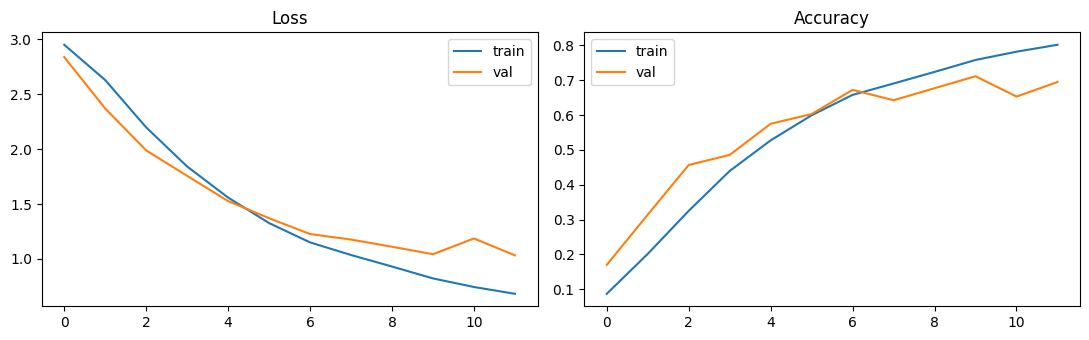

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(history.history["loss"], label="train"); ax[0].plot(history.history["val_loss"], label="val"); ax[0].set_title("Loss"); ax[0].legend()
ax[1].plot(history.history["accuracy"], label="train"); ax[1].plot(history.history["val_accuracy"], label="val"); ax[1].set_title("Accuracy"); ax[1].legend()
plt.tight_layout(); plt.show()

In [ ]:
# --- 7.4 Extract learned embeddings and query nearest neighbours ---
keras_emb = model.get_layer("embedding").get_weights()[0]
keras_vocab = vectorizer.get_vocabulary()
keras_idx = {w: i for i, w in enumerate(keras_vocab)}

def keras_similar(word, k=5):
    if word not in keras_idx:
        return []
    v = keras_emb[keras_idx[word]][None, :]
    sims = cosine_similarity(v, keras_emb).ravel(); sims[keras_idx[word]] = -1
    top = sims.argsort()[::-1][:k]
    return [(keras_vocab[j], round(float(sims[j]), 3)) for j in top]

for w in query_words:
    print(f"{w:10s} ->", [x for x, _ in keras_similar(w)])

space      -> [np.str_('lunar'), np.str_('orbiter'), np.str_('orbiting'), np.str_('telescopes'), np.str_('nasa')]
god        -> [np.str_('luke'), np.str_('luther'), np.str_('eternal'), np.str_('bible'), np.str_('protestants')]
car        -> [np.str_('taurus'), np.str_('camry'), np.str_('cars'), np.str_('toyota'), np.str_('gt')]
game       -> [np.str_('player'), np.str_('season'), np.str_('scored'), np.str_('team'), np.str_('announcer')]
doctor     -> [np.str_('foods'), np.str_('msg'), np.str_('medicine'), np.str_('infection'), np.str_('infections')]


**Observation.** Keras embeddings are *task-specific*: neighbours reflect words that help predict the same newsgroup label, so topical words cluster well, but general-language relations (analogies, synonyms) are weaker than Word2Vec/GloVe because the objective is classification, not language modelling.

# 8. Contextual Embeddings — BERT and SBERT

In static embeddings a word has exactly **one** vector. BERT produces a **different** vector for every occurrence, depending on the sentence.

### 8.1 BERT: the word *"bank"* in different contexts

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT parameters: 109.5M


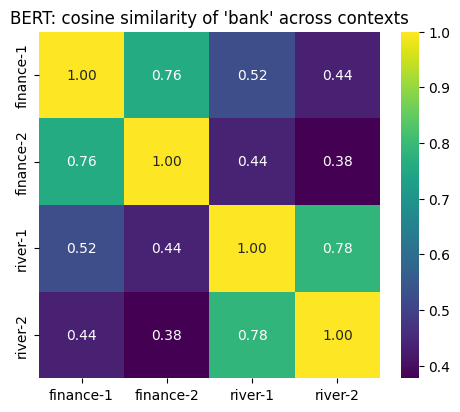

Static Word2Vec: 'bank' always has ONE vector -> similarity between any two uses = 1.00
Word2Vec nearest neighbours of 'bank': ['bcci', 'mortgage', 'cash', 'banking', 'rubles']


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel

tok = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased").eval()
print("BERT parameters: %.1fM" % (sum(p.numel() for p in bert.parameters()) / 1e6))

def bert_word_vec(sentence, word):
    enc = tok(sentence, return_tensors="pt")
    with torch.no_grad():
        hidden = bert(**enc).last_hidden_state[0]
    toks = tok.convert_ids_to_tokens(enc["input_ids"][0])
    return hidden[toks.index(word)].numpy()

bank_sentences = [
    "He deposited the cheque at the bank before noon.",
    "The bank approved my home loan application.",
    "We sat on the river bank and watched the water flow.",
    "Wild flowers grew along the muddy bank of the stream.",
]
bank_vecs = np.array([bert_word_vec(s, "bank") for s in bank_sentences])
sim_bert = cosine_similarity(bank_vecs)

labels_s = ["finance-1", "finance-2", "river-1", "river-2"]
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(sim_bert, annot=True, fmt=".2f", cmap="viridis", xticklabels=labels_s, yticklabels=labels_s)
plt.title("BERT: cosine similarity of 'bank' across contexts"); plt.show()

print("Static Word2Vec: 'bank' always has ONE vector -> similarity between any two uses = 1.00")
print("Word2Vec nearest neighbours of 'bank':", [w for w, _ in w2v_sg.wv.most_similar("bank", topn=5)] if "bank" in w2v_sg.wv else "n/a")

In [ ]:
# More polysemous words: "apple", "python", "light"
tests = {
    "apple":  ["She ate a fresh apple for lunch.", "Apple released a new phone this year."],
    "light":  ["Turn on the light, it is too dark.", "This bag is very light to carry."],
    "python": ["The python slithered through the grass.", "I wrote the script in python yesterday."],
}
rows = []
for w, (s1, s2) in tests.items():
    v1, v2 = bert_word_vec(s1, w), bert_word_vec(s2, w)
    rows.append({"word": w, "BERT cosine (context 1 vs 2)": round(float(cosine_similarity([v1], [v2])[0, 0]), 3),
                 "Static embedding cosine": 1.0})
display(pd.DataFrame(rows).set_index("word"))

# BERT sub-word tokenisation handles OOV words
for w in ["computr", "unfathomable", "bioinformatics"]:
    print(f"{w:16s} -> {tok.tokenize(w)}")

,BERT cosine (context 1 vs 2),Static embedding cosine
word,,
apple,0.253,1.0
light,0.387,1.0
python,0.522,1.0


computr          -> ['com', '##put', '##r']
unfathomable     -> ['un', '##fat', '##hom', '##able']
bioinformatics   -> ['bio', '##in', '##form', '##atics']


### 8.2 SBERT: sentence embeddings

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

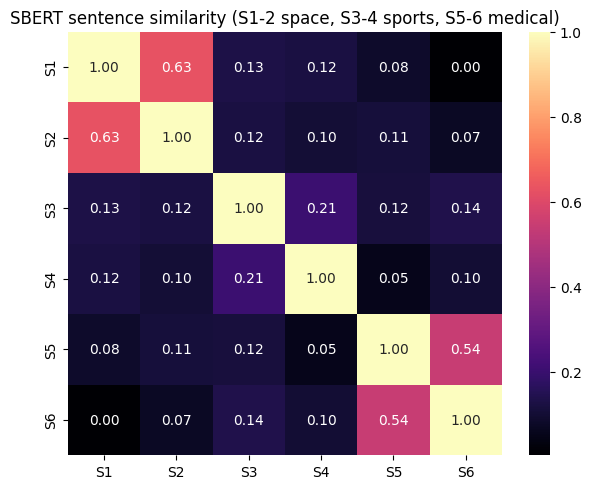

S1: NASA launched a new satellite into orbit.
S2: The space agency sent a spacecraft to the moon.
S3: The pitcher threw a fastball in the baseball game.
S4: The team won the championship after a thrilling match.
S5: The doctor prescribed medicine for the infection.
S6: The patient was treated at the hospital.


In [ ]:
from sentence_transformers import SentenceTransformer

t0 = time.time()
sbert = SentenceTransformer("all-MiniLM-L6-v2")
sents = [
    "NASA launched a new satellite into orbit.",
    "The space agency sent a spacecraft to the moon.",
    "The pitcher threw a fastball in the baseball game.",
    "The team won the championship after a thrilling match.",
    "The doctor prescribed medicine for the infection.",
    "The patient was treated at the hospital.",
]
S = sbert.encode(sents)
timings["SBERT (load + encode)"] = time.time() - t0
sim_s = cosine_similarity(S)
plt.figure(figsize=(7, 5.5))
sns.heatmap(sim_s, annot=True, fmt=".2f", cmap="magma",
            xticklabels=[f"S{i+1}" for i in range(len(sents))], yticklabels=[f"S{i+1}" for i in range(len(sents))])
plt.title("SBERT sentence similarity (S1-2 space, S3-4 sports, S5-6 medical)"); plt.show()
for i, s in enumerate(sents): print(f"S{i+1}: {s}")

### 8.3 Static vs Contextual — summary

| Aspect | Static (Word2Vec / GloVe / FastText) | Contextual (BERT) |
|---|---|---|
| Vector per word | One fixed vector | Different vector for each occurrence |
| Polysemy (*bank*, *apple*) | Merged into one average meaning | Separated by context (cosine < 1) |
| Sentence understanding | Must average word vectors | Native, via self-attention |
| Training / inference cost | Low | High (110 M parameters for BERT-base) |

# 9. Embedding Visualization

We project the 100-d Word2Vec vectors into 2-D using **PCA** (linear), **t-SNE** and **UMAP** (non-linear), and also export the vectors to the **TensorFlow Embedding Projector**.

In [ ]:
topic_words = {
    "space":      ["space", "nasa", "orbit", "shuttle", "moon", "launch", "satellite", "mission"],
    "sports":     ["baseball", "game", "team", "players", "season", "pitcher", "hockey", "league"],
    "computers":  ["computer", "software", "graphics", "image", "windows", "files", "program", "disk"],
    "medicine":   ["doctor", "medical", "disease", "patients", "health", "treatment", "drug", "cancer"],
    "automotive": ["car", "engine", "bike", "dealer", "cars", "oil", "drive", "speed"],
    "religion":   ["god", "jesus", "church", "bible", "faith", "christian", "religion", "christ"],
}
words, groups = [], []
for g, ws in topic_words.items():
    for w in ws:
        if w in w2v_sg.wv:
            words.append(w); groups.append(g)
vecs = np.array([w2v_sg.wv[w] for w in words])
print(len(words), "words selected")

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

proj = {
    "PCA": PCA(n_components=2, random_state=42).fit_transform(vecs),
    "t-SNE": TSNE(n_components=2, perplexity=10, random_state=42, init="pca").fit_transform(vecs),
    "UMAP": umap.UMAP(n_neighbors=10, min_dist=0.3, random_state=42).fit_transform(vecs),
}

palette = dict(zip(topic_words.keys(), sns.color_palette("tab10", len(topic_words))))
fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))
for ax, (name, p) in zip(axes, proj.items()):
    for g in topic_words:
        m = [i for i, x in enumerate(groups) if x == g]
        ax.scatter(p[m, 0], p[m, 1], label=g, color=palette[g], s=60)
    for i, w in enumerate(words):
        ax.annotate(w, (p[i, 0], p[i, 1]), fontsize=8, xytext=(3, 3), textcoords="offset points")
    ax.set_title(f"Word2Vec (Skip-gram) - {name}"); ax.grid(alpha=.3)
axes[0].legend(loc="best")
plt.tight_layout(); plt.savefig("embedding_projection_2d.png", dpi=150); plt.show()

In [ ]:
# Interactive 3-D PCA view
import plotly.express as px
p3 = PCA(n_components=3, random_state=42).fit_transform(vecs)
fig = px.scatter_3d(pd.DataFrame({"x": p3[:, 0], "y": p3[:, 1], "z": p3[:, 2], "word": words, "topic": groups}),
                    x="x", y="y", z="z", color="topic", text="word", title="Word2Vec embeddings - 3D PCA")
fig.update_traces(marker_size=4, textfont_size=9)
fig.show()

In [ ]:
# Compare the same words with BERT-derived (context-averaged) vectors? -> use GloVe for a second static view
gwords = [w for w in words if w in glove]
gvecs = np.array([glove[w] for w in gwords]); ggroups = [groups[words.index(w)] for w in gwords]
gp = TSNE(n_components=2, perplexity=10, random_state=42, init="pca").fit_transform(gvecs)
plt.figure(figsize=(8, 6.5))
for g in topic_words:
    m = [i for i, x in enumerate(ggroups) if x == g]
    plt.scatter(gp[m, 0], gp[m, 1], label=g, color=palette[g], s=60)
for i, w in enumerate(gwords): plt.annotate(w, (gp[i, 0], gp[i, 1]), fontsize=8, xytext=(3, 3), textcoords="offset points")
plt.title("GloVe (pretrained) - t-SNE"); plt.legend(); plt.grid(alpha=.3); plt.show()

In [ ]:
!pip install -q gensim
import numpy as np
from sklearn.datasets import fetch_20newsgroups
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
from gensim.models import Word2Vec

raw = fetch_20newsgroups(subset="all", remove=("headers", "footers", "quotes"))
prep = lambda t: [w for w in simple_preprocess(t, deacc=True, min_len=2, max_len=20) if w not in STOPWORDS]
sentences = [s for s in (prep(t) for t in raw.data) if len(s) >= 10]

w2v_sg = Word2Vec(sentences, sg=1, vector_size=100, window=5, min_count=5, workers=4, epochs=10, seed=42)

# ---- Export for TensorFlow Embedding Projector ----
export_words = [w.strip() for w in w2v_sg.wv.index_to_key[:5000] if w.strip()]
with open("vectors.tsv", "w", encoding="utf-8") as fv, open("metadata.tsv", "w", encoding="utf-8") as fm:
    for w in export_words:
        fv.write("\t".join(f"{x:.6f}" for x in w2v_sg.wv[w]) + "\n")
        fm.write(w + "\n")          # no header row

n_v = sum(1 for _ in open("vectors.tsv", encoding="utf-8"))
n_m = sum(1 for _ in open("metadata.tsv", encoding="utf-8"))
print(f"vectors.tsv: {n_v} | metadata.tsv: {n_m} | match = {n_v == n_m}")

from google.colab import files
files.download("vectors.tsv"); files.download("metadata.tsv")

vectors.tsv: 5000 | metadata.tsv: 5000 | match = True


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 10. Comparative Analysis

### 10.1 Measured results from this notebook

In [ ]:
summary = pd.DataFrame({
    "Technique": ["TF-IDF (word vectors)", "Word2Vec Skip-gram", "Word2Vec CBOW", "FastText", "GloVe (pretrained)", "Keras Embedding", "BERT-base", "SBERT MiniLM"],
    "Dimension": [X.shape[0], 100, 100, 100, 100, EMB_DIM, 768, 384],
    "Vector type": ["Sparse"] + ["Dense"] * 7,
    "Handles OOV": ["No", "No", "No", "Yes (char n-grams)", "No", "No (UNK)", "Yes (WordPiece)", "Yes (WordPiece)"],
    "Context-aware": ["No", "No", "No", "No", "No", "No", "Yes", "Yes"],
    "Time measured (s)": [round(timings.get("TF-IDF (fit)", np.nan), 1), round(timings["Word2Vec Skip-gram (train)"], 1),
                          round(timings["Word2Vec CBOW (train)"], 1), round(timings["FastText (train)"], 1),
                          round(timings["GloVe (load pretrained)"], 1), round(timings["Keras Embedding (train)"], 1),
                          np.nan, round(timings["SBERT (load + encode)"], 1)],
}).set_index("Technique")
display(summary)

### 10.2 Comparison on the four required criteria

| Criterion | Traditional (BoW / TF-IDF) | Static (Word2Vec / GloVe / FastText) | Contextual (BERT / SBERT) |
|---|---|---|---|
| **Semantic representation** | Weak. Words are independent features; *car* and *automobile* are unrelated. | Strong. Similar words lie close in vector space; supports analogies. | Strongest. Captures meaning in sentence context and nuanced relations. |
| **Out-of-vocabulary words** | Fails (word ignored). | Word2Vec/GloVe fail; **FastText** succeeds through character n-grams. | Succeeds through sub-word tokenisation (WordPiece/BPE). |
| **Contextual understanding** | None (n-grams capture only local order). | None — one vector per word, polysemy is averaged out. | Full — vector of *bank* differs between river and finance contexts. |
| **Computational requirements** | Very low; fits in seconds on CPU, but huge sparse matrices. | Low–medium; minutes on CPU, small dense models (100–300-d). | High; 110 M+ parameters, GPU preferred, 512-token limit; pretrained models avoid training cost. |

### 10.3 Key findings
1. **Traditional → static:** moving from sparse count vectors to dense learned vectors dramatically improves semantic similarity (Section 4 vs Section 5 neighbours) and reduces dimensionality from tens of thousands to ~100.
2. **Skip-gram vs CBOW:** Skip-gram gives better rare-word vectors; CBOW trains faster.
3. **FastText vs Word2Vec:** FastText can embed misspelt/unseen words (Section 6), at the cost of a larger model and longer training.
4. **Corpus size matters:** pretrained GloVe solves analogies that models trained on our small corpus cannot.
5. **Keras embeddings** are task-specific and ideal when labelled data is available and the embedding is only a component of a larger model.
6. **Static → contextual:** BERT gives different vectors for the same word in different sentences (Section 8), resolving polysemy, but is far more expensive.
7. **Visualization** (PCA/t-SNE/UMAP/Embedding Projector) confirms topic clusters; non-linear methods separate them best.

### 10.4 When to use what
* Quick baseline / small data, interpretable features → **TF-IDF + linear model**
* Domain-specific static vectors, limited compute → **Word2Vec / FastText**
* Noisy text with typos, rare words, rich morphology → **FastText**
* Polysemy, QA, NER, semantic search, state-of-the-art accuracy → **BERT / RoBERTa / SBERT**

# 11. Conclusion

This self-learning assignment traced the evolution of word representations from sparse count-based vectors (One-Hot, BoW, TF-IDF) through dense static embeddings (Word2Vec, GloVe, FastText, Keras Embedding layer) to contextual Transformer embeddings (BERT, SBERT). Using a common dataset (20 Newsgroups) we generated TF-IDF, Word2Vec, FastText, GloVe, Keras and BERT representations, retrieved the five most similar words by cosine similarity, demonstrated FastText's OOV handling and BERT's context-dependent vectors, and visualized embeddings with PCA, t-SNE, UMAP and the TensorFlow Embedding Projector. The trade-off is clear: **richer semantics and context come at higher computational cost.**


